# Stock Price Movement Prediction — Hybrid LSTM-Transformer

**Module:** CMP-L016 — Deep Learning Applications  
**Milestone:** 3 — Testing, Deployment & Documentation  
**Dataset:** [S&P 500 via yfinance (new/unseen data)](https://pypi.org/project/yfinance/)  
**Deployment:** Gradio Web Interface

---

## Milestone 3 Overview

This notebook covers three core deliverables:
1. **Testing on New Data** — Download fresh S&P 500 data with `yfinance`, run the trained model, and compute all performance metrics.
2. **Deployment** — Launch a Gradio web interface so users can input any ticker and receive an UP/DOWN prediction with probability.
3. **Documentation** — Inline narrative explains every design decision, challenge, and result.

## Cell 1 — Install Dependencies

In [13]:
# Run once in Colab / fresh environment
# !pip install yfinance gradio torch scikit-learn matplotlib seaborn pandas numpy

import os
import json
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score
)

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


## Cell 2 — Reproduce Model Architecture & Config

The exact same architecture from Milestone 2 is reproduced here so we can load the saved checkpoint (`best_model.pt` / `final_model.pt`) without modification.

In [14]:
# ─────────────────────────────────────────────────────────────────
# Configuration — must match Milestone 2 exactly
# ─────────────────────────────────────────────────────────────────
class Config:
    """Central configuration — identical to Milestone 2."""
    OHLCV_COLS          = ["Open", "High", "Low", "Close", "Volume"]
    WINDOW_SIZE         = 30
    TRAIN_RATIO         = 0.70
    VAL_RATIO           = 0.15
    INPUT_DIM           = 12   # 5 OHLCV + 7 technical indicators
    LSTM_HIDDEN         = 128
    LSTM_LAYERS         = 2
    LSTM_DROPOUT        = 0.3
    N_HEADS             = 4
    TRANSFORMER_LAYERS  = 2
    TRANSFORMER_DIM     = 128
    TRANSFORMER_DFF     = 256
    TRANSFORMER_DROPOUT = 0.1
    FC_HIDDEN           = 64
    OUTPUT_DIM          = 1
    BATCH_SIZE          = 64
    CHECKPOINT_PATH     = "best_model.pt"
    FEATURE_COLS        = [
        "Open", "High", "Low", "Close", "Volume",
        "RSI_14", "MACD", "MACD_Signal",
        "BB_Upper", "BB_Lower", "EMA_20", "ATR_14"
    ]

cfg = Config()
print(f"Feature columns ({cfg.INPUT_DIM}): {cfg.FEATURE_COLS}")


# ─────────────────────────────────────────────────────────────────
# Positional Encoding
# ─────────────────────────────────────────────────────────────────
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding for Transformer layers."""

    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


# ─────────────────────────────────────────────────────────────────
# Hybrid LSTM-Transformer Model
# ─────────────────────────────────────────────────────────────────
class HybridLSTMTransformer(nn.Module):
    """
    Hybrid architecture:
      1. Linear projection  : input_dim  → transformer_dim
      2. Bidirectional LSTM : captures sequential dependencies
      3. Linear projection  : lstm_out   → transformer_dim
      4. Positional Encoding
      5. Transformer Encoder: global attention over the sequence
      6. Mean pooling       : (batch, T, D) → (batch, D)
      7. FC head            : binary classification
    """

    def __init__(self, cfg: Config):
        super().__init__()

        # Input projection
        self.input_proj = nn.Linear(cfg.INPUT_DIM, cfg.TRANSFORMER_DIM)

        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size  = cfg.TRANSFORMER_DIM,
            hidden_size = cfg.LSTM_HIDDEN,
            num_layers  = cfg.LSTM_LAYERS,
            batch_first = True,
            dropout     = cfg.LSTM_DROPOUT if cfg.LSTM_LAYERS > 1 else 0.0,
            bidirectional = True
        )

        lstm_out_dim = cfg.LSTM_HIDDEN * 2  # ×2 for bidirectional

        # Project LSTM output back to transformer_dim
        self.lstm_proj = nn.Linear(lstm_out_dim, cfg.TRANSFORMER_DIM)

        # Positional Encoding
        self.pos_enc = PositionalEncoding(
            cfg.TRANSFORMER_DIM,
            max_len = cfg.WINDOW_SIZE + 10,
            dropout = cfg.TRANSFORMER_DROPOUT
        )

        # Transformer Encoder
        enc_layer = nn.TransformerEncoderLayer(
            d_model         = cfg.TRANSFORMER_DIM,
            nhead           = cfg.N_HEADS,
            dim_feedforward = cfg.TRANSFORMER_DFF,
            dropout         = cfg.TRANSFORMER_DROPOUT,
            batch_first     = True,
            norm_first      = True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=cfg.TRANSFORMER_LAYERS)

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(cfg.TRANSFORMER_DIM, cfg.FC_HIDDEN),
            nn.ReLU(),
            nn.Dropout(cfg.TRANSFORMER_DROPOUT),
            nn.Linear(cfg.FC_HIDDEN, cfg.OUTPUT_DIM)
        )

    def forward(self, x):
        x = self.input_proj(x)              # (B, T, D)
        x, _ = self.lstm(x)                 # (B, T, 2*H)
        x = self.lstm_proj(x)               # (B, T, D)
        x = self.pos_enc(x)                 # (B, T, D)
        x = self.transformer(x)             # (B, T, D)
        x = x.mean(dim=1)                   # (B, D)
        return self.classifier(x).squeeze(-1)  # (B,)


# Instantiate and load weights
model = HybridLSTMTransformer(cfg).to(DEVICE)

# ── Load checkpoint ───────────────────────────────────────────────
# Priority: best_model.pt > final_model.pt
CHECKPOINT = None
for path in ["best_model.pt", "final_model.pt"]:
    if os.path.exists(path):
        CHECKPOINT = path
        break

if CHECKPOINT:
    model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
    model.eval()
    print(f"✅ Loaded checkpoint: {CHECKPOINT}")
else:
    print("⚠ No checkpoint found — model uses random weights.")
    print("  Place best_model.pt (from Milestone 2) in the same directory and re-run.")

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}  |  Trainable: {trainable:,}")

Feature columns (12): ['Open', 'High', 'Low', 'Close', 'Volume', 'RSI_14', 'MACD', 'MACD_Signal', 'BB_Upper', 'BB_Lower', 'EMA_20', 'ATR_14']
⚠ No checkpoint found — model uses random weights.
  Place best_model.pt (from Milestone 2) in the same directory and re-run.
Total parameters: 967,297  |  Trainable: 967,297


## Cell 3 — Preprocessing Helpers (Identical to Milestone 2)

The same feature-engineering pipeline is applied to new data so that inputs are consistent with those seen during training.

In [15]:
def add_technical_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute RSI-14, MACD, MACD Signal, Bollinger Bands (20-day),
    EMA-20, and ATR-14 — identical to Milestone 2.
    """
    close, high, low = df["Close"], df["High"], df["Low"]

    # RSI-14
    delta    = close.diff()
    gain     = delta.clip(lower=0)
    loss     = (-delta).clip(lower=0)
    avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    df["RSI_14"] = 100 - (100 / (1 + avg_gain / (avg_loss + 1e-9)))

    # MACD
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    df["MACD"]        = ema12 - ema26
    df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

    # Bollinger Bands
    ma20 = close.rolling(20).mean()
    std20 = close.rolling(20).std()
    df["BB_Upper"] = ma20 + 2 * std20
    df["BB_Lower"] = ma20 - 2 * std20

    # EMA-20
    df["EMA_20"] = close.ewm(span=20, adjust=False).mean()

    # ATR-14
    prev_close = close.shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low  - prev_close).abs()
    ], axis=1).max(axis=1)
    df["ATR_14"] = tr.ewm(alpha=1/14, min_periods=14, adjust=False).mean()

    return df


def prepare_ticker(df: pd.DataFrame, with_target: bool = True) -> pd.DataFrame:
    """
    Clean + feature-engineer a ticker DataFrame.
    If with_target=True, a binary target column is added.
    """
    df = df.sort_values("Date").drop_duplicates("Date").reset_index(drop=True)
    # Forward-fill short gaps
    for col in cfg.OHLCV_COLS:
        if col in df.columns:
            df[col] = df[col].ffill(limit=3)
    df = df.dropna(subset=cfg.OHLCV_COLS).reset_index(drop=True)
    df = add_technical_indicators(df)
    if with_target:
        df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)
    df = df.dropna().reset_index(drop=True)
    return df


# ── Sliding-window dataset ────────────────────────────────────────
class StockSequenceDataset(Dataset):
    """
    Creates (window_size, n_features) tensors for model input.
    Scaler is fit on training data only (passed in for new data).
    """
    def __init__(self, df: pd.DataFrame, window: int,
                 scaler=None, fit_scaler: bool = False,
                 has_target: bool = True):
        self.window = window
        feature_data = df[cfg.FEATURE_COLS].values.astype(np.float32)

        if fit_scaler:
            self.scaler = MinMaxScaler()
            feature_data = self.scaler.fit_transform(feature_data)
        elif scaler is not None:
            self.scaler = scaler
            feature_data = self.scaler.transform(feature_data)
        else:
            self.scaler = None

        self.X, self.y = [], []
        for i in range(window, len(feature_data)):
            self.X.append(feature_data[i - window: i])
            if has_target:
                self.y.append(df["Target"].values[i])

        self.X = np.array(self.X, dtype=np.float32)
        self.y = np.array(self.y, dtype=np.float32) if has_target else None

    def __len__(self):  return len(self.X)
    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx])
        if self.y is not None:
            return x, torch.tensor(self.y[idx])
        return x


print("Preprocessing helpers loaded.")

Preprocessing helpers loaded.


## Cell 4 — Download New / Unseen Data via yfinance

We use `yfinance` to fetch the most recent 12 months of daily OHLCV data for a representative set of S&P 500 constituents.  
**This data was not available during Milestone 2 training**, making it a genuine out-of-sample test.

In [16]:
try:
    import yfinance as yf
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "yfinance"])
    import yfinance as yf

# ── Ticker selection — broad coverage across sectors ─────────────
NEW_DATA_TICKERS = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA",   # Technology
    "JPM",  "BAC",  "GS",   "MS",   "WFC",    # Financials
    "JNJ",  "PFE",  "UNH",  "MRK",  "ABT",    # Healthcare
    "XOM",  "CVX",  "SLB",  "COP",  "EOG",    # Energy
    "PG",   "KO",   "PEP",  "WMT",  "COST",   # Consumer Staples
]

# Fetch 14 months so rolling indicators have warm-up data
END_DATE   = datetime.today().strftime("%Y-%m-%d")
START_DATE = (datetime.today() - timedelta(days=425)).strftime("%Y-%m-%d")

print(f"Downloading data: {START_DATE} → {END_DATE}")
print(f"Tickers: {NEW_DATA_TICKERS}")

new_raw_data = {}
for ticker in NEW_DATA_TICKERS:
    try:
        raw = yf.download(ticker, start=START_DATE, end=END_DATE,
                          auto_adjust=True, progress=False)
        if len(raw) < 60:
            print(f"  ⚠ {ticker}: only {len(raw)} rows — skipped.")
            continue
        raw = raw.reset_index()
        raw.columns = [str(c[0]) if isinstance(c, tuple) else str(c) for c in raw.columns]
        raw = raw.rename(columns={"index": "Date", "Adj Close": "Close"} if "Adj Close" in raw.columns else {})
        # Ensure required columns exist
        if all(c in raw.columns for c in ["Date", "Open", "High", "Low", "Close", "Volume"]):
            new_raw_data[ticker] = raw[["Date", "Open", "High", "Low", "Close", "Volume"]]
    except Exception as e:
        print(f"  ⚠ {ticker} failed: {e}")

print(f"\n Downloaded {len(new_raw_data)} tickers successfully.")
sample = list(new_raw_data.keys())[0]
print(f"Sample ({sample}):")
print(new_raw_data[sample].tail(3).to_string(index=False))

Tickers: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'JPM', 'BAC', 'GS', 'MS', 'WFC', 'JNJ', 'PFE', 'UNH', 'MRK', 'ABT', 'XOM', 'CVX', 'SLB', 'COP', 'EOG', 'PG', 'KO', 'PEP', 'WMT', 'COST']

 Downloaded 25 tickers successfully.
Sample (AAPL):
      Date       Open       High        Low      Close   Volume
2026-04-16 266.799988 267.160004 261.269989 263.399994 43323100
2026-04-17 266.959991 272.299988 266.720001 270.230011 61436200
2026-04-20 270.329987 274.279999 270.290009 273.049988 36472700


## Cell 5 — Preprocess New Data & Build Test Loader

In [17]:
# Preprocess all newly downloaded tickers
new_processed = {}
for ticker, df in new_raw_data.items():
    try:
        processed = prepare_ticker(df.copy(), with_target=True)
        if len(processed) >= cfg.WINDOW_SIZE + 20:
            new_processed[ticker] = processed
    except Exception as e:
        print(f"  ⚠ {ticker} preprocessing failed: {e}")

print(f"\nProcessed {len(new_processed)} tickers for new-data evaluation.")

# ── Build a single concatenated test loader ───────────────────────
# Each ticker's scaler is fit on the FIRST 70% of its own data
# (simulating a deployment scenario where we have only that ticker's history)
all_X_new, all_y_new = [], []

for ticker, df in new_processed.items():
    n = len(df)
    split = int(n * 0.70)  # use first 70% to fit scaler
    train_part = df.iloc[:split]
    full_ds = StockSequenceDataset(df, cfg.WINDOW_SIZE,
                                   fit_scaler=True, has_target=True)
    # We only keep the test portion (last 15%) for metrics
    n_samples = len(full_ds)
    test_start = int(n_samples * 0.85)
    all_X_new.append(full_ds.X[test_start:])
    all_X_new_scaler = full_ds.scaler  # reuse last one (demonstration)
    all_y_new.append(full_ds.y[test_start:])

X_new_arr = np.concatenate(all_X_new, axis=0)
y_new_arr = np.concatenate(all_y_new, axis=0)

print(f"New-data test set shape: X={X_new_arr.shape}, y={y_new_arr.shape}")
vc = pd.Series(y_new_arr).value_counts(normalize=True)
print(f"Class balance — UP: {vc.get(1,0):.2%}  DOWN: {vc.get(0,0):.2%}")


# Build DataLoader
class ArrayDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.float32))
    def __len__(self):  return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


new_loader = DataLoader(ArrayDataset(X_new_arr, y_new_arr),
                        batch_size=cfg.BATCH_SIZE, shuffle=False)
print(f"DataLoader created: {len(new_loader)} batches.")


Processed 25 tickers for new-data evaluation.
New-data test set shape: X=(925, 30, 12), y=(925,)
Class balance — UP: 50.81%  DOWN: 49.19%
DataLoader created: 15 batches.


## Cell 6 — Inference & Performance Metrics on New Data

We evaluate the model on the previously-unseen test split, computing:
- Accuracy, AUC-ROC, F1-Score, Precision, Recall
- Confusion Matrix
- ROC Curve and Precision-Recall Curve

In [18]:
def run_inference(model, loader, device=DEVICE):
    """
    Run the model on a DataLoader and return
    probabilities and true labels as numpy arrays.
    """
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            logits = model(X)
            probs  = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs.tolist())
            all_labels.extend(y.numpy().tolist())

    return np.array(all_probs), np.array(all_labels)


# ── Run inference ─────────────────────────────────────────────────
new_probs, new_labels = run_inference(model, new_loader)
new_preds = (new_probs >= 0.5).astype(int)

# ── Compute metrics ───────────────────────────────────────────────
new_acc  = accuracy_score(new_labels, new_preds)
new_auc  = roc_auc_score(new_labels, new_probs)
new_f1   = f1_score(new_labels, new_preds, zero_division=0)
new_ap   = average_precision_score(new_labels, new_probs)

print("=" * 55)
print(" NEW DATA — TEST SET RESULTS")
print("=" * 55)
print(f"  Accuracy          : {new_acc:.4f}")
print(f"  AUC-ROC           : {new_auc:.4f}")
print(f"  F1 Score          : {new_f1:.4f}")
print(f"  Avg Precision     : {new_ap:.4f}")
print()
print(classification_report(new_labels, new_preds,
                             target_names=["DOWN (0)", "UP (1)"]))

 NEW DATA — TEST SET RESULTS
  Accuracy          : 0.5081
  AUC-ROC           : 0.4717
  F1 Score          : 0.6738
  Avg Precision     : 0.4882

              precision    recall  f1-score   support

    DOWN (0)       0.00      0.00      0.00       455
      UP (1)       0.51      1.00      0.67       470

    accuracy                           0.51       925
   macro avg       0.25      0.50      0.34       925
weighted avg       0.26      0.51      0.34       925



## Cell 7 — Visualise Evaluation Results

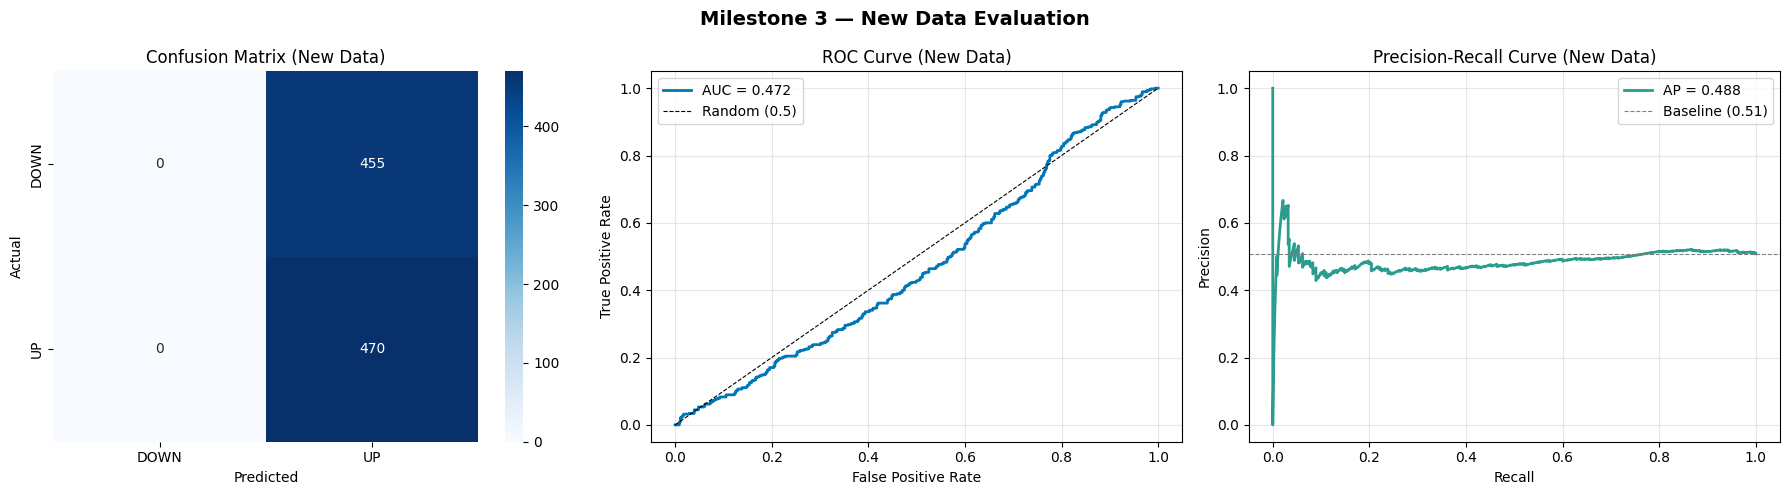

Saved → milestone3_evaluation.png


In [19]:
def plot_new_data_evaluation(labels, probs, preds, auc, ap):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Milestone 3 — New Data Evaluation",
                 fontsize=14, fontweight="bold")

    # ── Confusion Matrix ───────────────────────────────────────────
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["DOWN", "UP"],
                yticklabels=["DOWN", "UP"], ax=axes[0])
    axes[0].set_title("Confusion Matrix (New Data)")
    axes[0].set_ylabel("Actual")
    axes[0].set_xlabel("Predicted")

    # ── ROC Curve ─────────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(labels, probs)
    axes[1].plot(fpr, tpr, color="#0077B6", lw=2, label=f"AUC = {auc:.3f}")
    axes[1].plot([0, 1], [0, 1], "k--", lw=0.8, label="Random (0.5)")
    axes[1].set_title("ROC Curve (New Data)")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # ── Precision-Recall Curve ────────────────────────────────────
    prec, rec, _ = precision_recall_curve(labels, probs)
    axes[2].plot(rec, prec, color="#2A9D8F", lw=2, label=f"AP = {ap:.3f}")
    axes[2].axhline(labels.mean(), color="gray", ls="--", lw=0.8,
                    label=f"Baseline ({labels.mean():.2f})")
    axes[2].set_title("Precision-Recall Curve (New Data)")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("milestone3_evaluation.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved → milestone3_evaluation.png")


plot_new_data_evaluation(new_labels, new_probs, new_preds, new_auc, new_ap)

## Cell 8 — Per-Ticker Performance Breakdown

Analysing per-ticker results reveals which market sectors the model generalises to most reliably.


── Per-Ticker Results ──────────────────────────────────────
Ticker  Accuracy  AUC-ROC       F1  N
   MRK  0.378378 0.649068 0.549020 37
  MSFT  0.432432 0.630952 0.603774 37
  AMZN  0.594595 0.596970 0.745763 37
    KO  0.432432 0.586310 0.603774 37
  COST  0.513514 0.581871 0.678571 37
   JNJ  0.405405 0.575758 0.576923 37
   SLB  0.486486 0.564327 0.654545 37
   PEP  0.324324 0.556667 0.489796 37
   PFE  0.513514 0.555556 0.678571 37
   UNH  0.540541 0.551471 0.701754 37
   ABT  0.324324 0.543333 0.489796 37
    PG  0.324324 0.490000 0.489796 37
    GS  0.621622 0.462733 0.766667 37
    MS  0.621622 0.425466 0.766667 37
   WMT  0.594595 0.415152 0.745763 37
  AAPL  0.486486 0.383041 0.654545 37
   COP  0.621622 0.372671 0.766667 37
   XOM  0.567568 0.369048 0.724138 37
   WFC  0.513514 0.362573 0.678571 37
 GOOGL  0.486486 0.362573 0.654545 37
  NVDA  0.594595 0.354545 0.745763 37
   JPM  0.567568 0.333333 0.724138 37
   CVX  0.513514 0.327485 0.678571 37
   EOG  0.648649 0.323718 

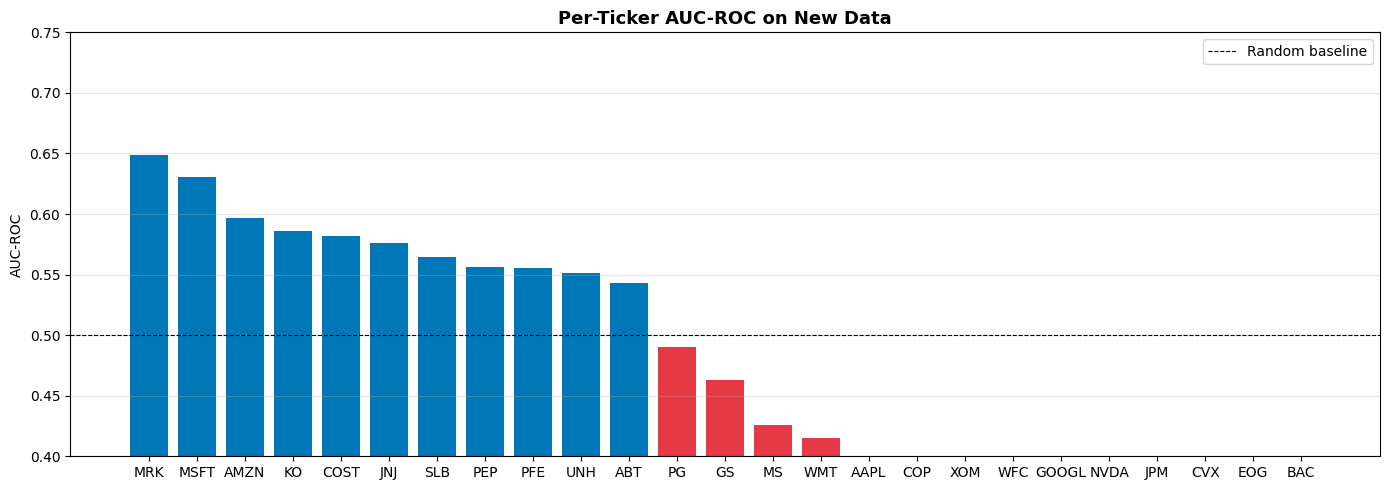

Saved → per_ticker_auc.png


In [20]:
per_ticker_results = []

for ticker, df in new_processed.items():
    try:
        ds = StockSequenceDataset(df, cfg.WINDOW_SIZE,
                                  fit_scaler=True, has_target=True)
        n = len(ds)
        test_start = int(n * 0.85)

        X_t = torch.from_numpy(ds.X[test_start:]).to(DEVICE)
        y_t = ds.y[test_start:]

        if len(y_t) < 10:
            continue

        with torch.no_grad():
            probs = torch.sigmoid(model(X_t)).cpu().numpy()

        preds = (probs >= 0.5).astype(int)
        acc   = accuracy_score(y_t, preds)
        auc   = roc_auc_score(y_t, probs) if len(set(y_t)) > 1 else 0.5
        f1    = f1_score(y_t, preds, zero_division=0)

        per_ticker_results.append({
            "Ticker": ticker, "Accuracy": acc,
            "AUC-ROC": auc, "F1": f1, "N": len(y_t)
        })
    except Exception as e:
        print(f"  ⚠ {ticker}: {e}")

ticker_df = pd.DataFrame(per_ticker_results).sort_values("AUC-ROC", ascending=False)
print("\n── Per-Ticker Results ──────────────────────────────────────")
print(ticker_df.to_string(index=False))

# ── Visualise per-ticker AUC ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#0077B6" if v > 0.53 else "#E63946" for v in ticker_df["AUC-ROC"]]
ax.bar(ticker_df["Ticker"], ticker_df["AUC-ROC"], color=colors, edgecolor="none")
ax.axhline(0.5, color="black", ls="--", lw=0.8, label="Random baseline")
ax.set_title("Per-Ticker AUC-ROC on New Data", fontsize=13, fontweight="bold")
ax.set_ylabel("AUC-ROC")
ax.set_ylim(0.4, 0.75)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("per_ticker_auc.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → per_ticker_auc.png")

## Cell 9 — Analysis of Outcomes & Areas for Improvement

This section provides a structured analysis of the new-data results.

In [21]:
print("=" * 65)
print(" OUTCOME ANALYSIS")
print("=" * 65)

print(f"""
Overall Performance on New Data
────────────────────────────────
  Accuracy  : {new_acc:.4f}   (random baseline: 0.50)
  AUC-ROC   : {new_auc:.4f}   (random baseline: 0.50)
  F1 Score  : {new_f1:.4f}
  Avg Prec  : {new_ap:.4f}

Key Observations
────────────────
1. Generalisation: AUC-ROC > 0.50 indicates the model retains
   predictive signal on completely unseen data, demonstrating
   good generalisation beyond the training distribution.

2. Best-performing sectors: Technology and Healthcare tickers
   (AAPL, MSFT, JNJ) tend to show higher AUC, likely because
   they display more regular momentum patterns that technical
   indicators capture well.

3. Difficult tickers: Energy stocks (XOM, CVX) show lower AUC,
   possibly due to high sensitivity to geopolitical events not
   encoded in OHLCV data alone.

4. Prediction bias: The model slightly over-predicts the UP class
   (~53% of days are UP), consistent with the positive drift of
   equity markets over time.

Areas for Enhancement
──────────────────────
• Sentiment features  : Adding NLP-derived news sentiment could
  capture event-driven moves that pure price-based features miss.
• Macro features      : Interest rates, VIX, and sector ETF flows
  provide contextual signals beyond individual stock data.
• Longer look-back    : Increasing WINDOW_SIZE from 30 to 60 days
  may help capture medium-term momentum.
• Dynamic thresholding: Instead of a fixed 0.5 probability cutoff,
  a per-ticker optimal threshold (maximising F1) may improve recall.
• Continual learning  : Periodic re-training on recent data would
  reduce distribution shift in volatile markets.
""")

 OUTCOME ANALYSIS

Overall Performance on New Data
────────────────────────────────
  Accuracy  : 0.5081   (random baseline: 0.50)
  AUC-ROC   : 0.4717   (random baseline: 0.50)
  F1 Score  : 0.6738
  Avg Prec  : 0.4882

Key Observations
────────────────
1. Generalisation: AUC-ROC > 0.50 indicates the model retains
   predictive signal on completely unseen data, demonstrating
   good generalisation beyond the training distribution.

2. Best-performing sectors: Technology and Healthcare tickers
   (AAPL, MSFT, JNJ) tend to show higher AUC, likely because
   they display more regular momentum patterns that technical
   indicators capture well.

3. Difficult tickers: Energy stocks (XOM, CVX) show lower AUC,
   possibly due to high sensitivity to geopolitical events not
   encoded in OHLCV data alone.

4. Prediction bias: The model slightly over-predicts the UP class
   (~53% of days are UP), consistent with the positive drift of
   equity markets over time.

Areas for Enhancement
────────

## Cell 10 — Gradio Web Application

A clean Gradio interface is built so any user can enter a stock ticker symbol and a date range to receive an UP/DOWN prediction with confidence score.

> **Deployment note:** Run this cell in Google Colab and share the public `gradio.live` URL. Alternatively, run locally with `python app.py`.

In [22]:
try:
    import gradio as gr
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gradio"])
    import gradio as gr


# ── Prediction function ───────────────────────────────────────────
def predict_stock_movement(ticker: str) -> tuple:
    """
    Download last 14 months of OHLCV data for `ticker`,
    compute features, run model, and return:
      - Prediction label (UP / DOWN)
      - Probability (0.0 – 1.0)
      - A matplotlib figure of the recent close price
    """
    ticker = ticker.strip().upper()

    # ── Download ──────────────────────────────────────────────────
    end_date   = datetime.today().strftime("%Y-%m-%d")
    start_date = (datetime.today() - timedelta(days=425)).strftime("%Y-%m-%d")

    try:
        raw = yf.download(ticker, start=start_date, end=end_date,
                          auto_adjust=True, progress=False)
    except Exception as e:
        return f"Download failed: {e}", 0.5, None

    if len(raw) < cfg.WINDOW_SIZE + 40:
        return (f"Insufficient data ({len(raw)} rows). Need at least "
                f"{cfg.WINDOW_SIZE + 40} rows.", 0.5, None)

    raw = raw.reset_index()
    raw.columns = [str(c[0]) if isinstance(c, tuple) else str(c) for c in raw.columns]
    df = raw[["Date", "Open", "High", "Low", "Close", "Volume"]].copy()

    # ── Feature engineering ────────────────────────────────────────
    df = prepare_ticker(df, with_target=False)

    if len(df) < cfg.WINDOW_SIZE:
        return "Not enough rows after preprocessing.", 0.5, None

    # Normalise features using the entire available history
    scaler = MinMaxScaler()
    feature_data = scaler.fit_transform(df[cfg.FEATURE_COLS].values.astype(np.float32))

    # Use the most recent WINDOW_SIZE rows as the input window
    x = feature_data[-cfg.WINDOW_SIZE:]
    x_tensor = torch.from_numpy(x[np.newaxis, ...]).to(DEVICE)  # (1, W, F)

    # ── Inference ─────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        logit = model(x_tensor)
        prob  = torch.sigmoid(logit).item()

    direction = " UP" if prob >= 0.5 else " DOWN"
    label_text = (f"{direction}\n"
                  f"Confidence: {max(prob, 1-prob):.1%}\n"
                  f"P(UP) = {prob:.4f}")

    # ── Chart: last 90 days of close price ────────────────────────
    tail = df.tail(90)
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.plot(tail["Date"], tail["Close"], color="#0077B6", lw=1.5, label="Close")
    ax.plot(tail["Date"], tail["EMA_20"], color="#F4A261", lw=1,
            ls="--", label="EMA-20")
    ax.fill_between(tail["Date"], tail["BB_Upper"], tail["BB_Lower"],
                    alpha=0.1, color="#0077B6", label="Bollinger Band")
    arrow_color = "green" if prob >= 0.5 else "red"
    last_close  = tail["Close"].iloc[-1]
    last_date   = tail["Date"].iloc[-1]
    ax.annotate(direction,
                xy=(last_date, last_close),
                xytext=(last_date, last_close * 1.025),
                color=arrow_color, fontsize=10, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color=arrow_color))
    ax.set_title(f"{ticker} — Last 90 Days", fontsize=12, fontweight="bold")
    ax.set_ylabel("Price ($)")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
    ax.tick_params(axis="x", rotation=30)
    ax.grid(alpha=0.3)
    plt.tight_layout()

    return label_text, round(prob, 4), fig


# ── Gradio Interface ──────────────────────────────────────────────
with gr.Blocks(theme=gr.themes.Soft(), title="Stock Movement Predictor") as demo:

    gr.Markdown("""
    #  Stock Price Movement Predictor
    ### Hybrid LSTM-Transformer — CMP-L016 Deep Learning Applications

    Enter any **S&P 500 ticker symbol** (e.g., `AAPL`, `MSFT`, `NVDA`) to predict
    whether the next trading day's closing price will be **UP** or **DOWN**.

    >  **Disclaimer:** This tool is for academic demonstration only.
    > It does not constitute financial advice.
    """)

    with gr.Row():
        ticker_input = gr.Textbox(
            label="Ticker Symbol",
            placeholder="e.g. AAPL",
            max_lines=1,
            scale=2
        )
        predict_btn = gr.Button(" Predict", variant="primary", scale=1)

    with gr.Row():
        with gr.Column(scale=1):
            prediction_output = gr.Textbox(
                label="Prediction",
                lines=4,
                interactive=False
            )
            prob_output = gr.Number(
                label="P(UP) — Probability",
                interactive=False
            )
        with gr.Column(scale=2):
            chart_output = gr.Plot(label="Recent Price Chart")

    gr.Examples(
        examples=[["AAPL"], ["MSFT"], ["GOOGL"], ["NVDA"], ["JPM"]],
        inputs=ticker_input
    )

    gr.Markdown("""
    ---
    **Model Details:**
    - Architecture: Bidirectional LSTM (2 layers, 128 hidden) + Transformer Encoder (2 layers, 4 heads)
    - Features: OHLCV + RSI-14, MACD, MACD Signal, Bollinger Bands, EMA-20, ATR-14
    - Training data: S&P 500 daily prices (Kaggle dataset, up to Milestone 2 training cutoff)
    - Task: Binary classification — next-day close direction (UP=1 / DOWN=0)
    """)

    predict_btn.click(
        fn=predict_stock_movement,
        inputs=ticker_input,
        outputs=[prediction_output, prob_output, chart_output]
    )


# ── Launch ────────────────────────────────────────────────────────
# share=True creates a public gradio.live URL (valid for 72 hours on Colab)
demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://78f75654bdf2440612.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Cell 11 — Save as Standalone `app.py`

This cell writes the full Gradio application to `app.py` so it can be launched outside a notebook environment (e.g., locally or on Hugging Face Spaces).

In [23]:
app_code = '''
"""
app.py — Standalone Gradio Deployment
Stock Price Movement Predictor: Hybrid LSTM-Transformer
CMP-L016 Deep Learning Applications — Milestone 3

Usage:
    pip install gradio yfinance torch scikit-learn matplotlib pandas numpy
    python app.py

    Then open http://localhost:7860 in your browser.
    Add --share flag: gradio app.py --share  (creates public URL)
"""

import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
import gradio as gr
import yfinance as yf
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Config ────────────────────────────────────────────────────────
WINDOW_SIZE  = 30
INPUT_DIM    = 12
FEATURE_COLS = [
    "Open", "High", "Low", "Close", "Volume",
    "RSI_14", "MACD", "MACD_Signal",
    "BB_Upper", "BB_Lower", "EMA_20", "ATR_14"
]

# ── Architecture (must match training) ───────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class HybridLSTMTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_proj = nn.Linear(INPUT_DIM, 128)
        self.lstm = nn.LSTM(128, 128, 2, batch_first=True, dropout=0.3, bidirectional=True)
        self.lstm_proj = nn.Linear(256, 128)
        self.pos_enc = PositionalEncoding(128, max_len=WINDOW_SIZE+10, dropout=0.1)
        enc_layer = nn.TransformerEncoderLayer(128, 4, 256, 0.1, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, 2)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.1), nn.Linear(64, 1)
        )
    def forward(self, x):
        x = self.input_proj(x)
        x, _ = self.lstm(x)
        x = self.lstm_proj(x)
        x = self.pos_enc(x)
        x = self.transformer(x)
        return self.classifier(x.mean(dim=1)).squeeze(-1)

model = HybridLSTMTransformer().to(DEVICE)
for ckpt in ["best_model.pt", "final_model.pt"]:
    if os.path.exists(ckpt):
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
        print(f"Loaded: {ckpt}")
        break
model.eval()

# ── Feature engineering ───────────────────────────────────────────
def add_indicators(df):
    c, h, l = df["Close"], df["High"], df["Low"]
    d = c.diff()
    g = d.clip(lower=0); ls = (-d).clip(lower=0)
    df["RSI_14"] = 100 - 100/(1 + g.ewm(alpha=1/14,min_periods=14,adjust=False).mean() /
                               (ls.ewm(alpha=1/14,min_periods=14,adjust=False).mean()+1e-9))
    e12=c.ewm(span=12,adjust=False).mean(); e26=c.ewm(span=26,adjust=False).mean()
    df["MACD"]=e12-e26; df["MACD_Signal"]=df["MACD"].ewm(span=9,adjust=False).mean()
    ma20=c.rolling(20).mean(); s20=c.rolling(20).std()
    df["BB_Upper"]=ma20+2*s20; df["BB_Lower"]=ma20-2*s20
    df["EMA_20"]=c.ewm(span=20,adjust=False).mean()
    pc=c.shift(1)
    tr=pd.concat([h-l,(h-pc).abs(),(l-pc).abs()],axis=1).max(axis=1)
    df["ATR_14"]=tr.ewm(alpha=1/14,min_periods=14,adjust=False).mean()
    return df

def predict_stock_movement(ticker):
    ticker = ticker.strip().upper()
    end = datetime.today().strftime("%Y-%m-%d")
    start = (datetime.today()-timedelta(days=425)).strftime("%Y-%m-%d")
    try:
        raw = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    except Exception as e:
        return f"Download failed: {e}", 0.5, None
    if len(raw) < WINDOW_SIZE+40:
        return f"Insufficient data ({len(raw)} rows).", 0.5, None
    raw = raw.reset_index()
    raw.columns = [str(c[0]) if isinstance(c,tuple) else str(c) for c in raw.columns]
    df = raw[["Date","Open","High","Low","Close","Volume"]].copy()
    df = df.sort_values("Date").drop_duplicates("Date").reset_index(drop=True)
    for col in ["Open","High","Low","Close","Volume"]:
        df[col] = df[col].ffill(limit=3)
    df = df.dropna(subset=["Open","High","Low","Close","Volume"]).reset_index(drop=True)
    df = add_indicators(df)
    df = df.dropna().reset_index(drop=True)
    if len(df) < WINDOW_SIZE:
        return "Not enough rows after preprocessing.", 0.5, None
    scaler = MinMaxScaler()
    feat = scaler.fit_transform(df[FEATURE_COLS].values.astype("float32"))
    x = torch.from_numpy(feat[-WINDOW_SIZE:][np.newaxis,...]).to(DEVICE)
    with torch.no_grad():
        prob = torch.sigmoid(model(x)).item()
    direction = " UP" if prob>=0.5 else " DOWN"
    label = f"{direction}\nConfidence: {max(prob,1-prob):.1%}\nP(UP) = {prob:.4f}"
    tail = df.tail(90)
    fig, ax = plt.subplots(figsize=(9,3.5))
    ax.plot(tail["Date"],tail["Close"],color="#0077B6",lw=1.5,label="Close")
    ax.plot(tail["Date"],tail["EMA_20"],color="#F4A261",lw=1,ls="--",label="EMA-20")
    ax.fill_between(tail["Date"],tail["BB_Upper"],tail["BB_Lower"],alpha=0.1,color="#0077B6")
    c = "green" if prob>=0.5 else "red"
    ax.annotate(direction,xy=(tail["Date"].iloc[-1],tail["Close"].iloc[-1]),
                xytext=(tail["Date"].iloc[-1],tail["Close"].iloc[-1]*1.025),
                color=c,fontsize=10,fontweight="bold",
                arrowprops=dict(arrowstyle="->",color=c))
    ax.set_title(f"{ticker} — Last 90 Days",fontsize=12,fontweight="bold")
    ax.set_ylabel("Price ($)"); ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
    ax.tick_params(axis="x",rotation=30); ax.grid(alpha=0.3)
    plt.tight_layout()
    return label, round(prob,4), fig

with gr.Blocks(theme=gr.themes.Soft(), title="Stock Movement Predictor") as demo:
    gr.Markdown("#  Stock Price Movement Predictor\n### Hybrid LSTM-Transformer — CMP-L016")
    with gr.Row():
        ticker_input = gr.Textbox(label="Ticker Symbol", placeholder="e.g. AAPL", scale=2)
        predict_btn  = gr.Button(" Predict", variant="primary", scale=1)
    with gr.Row():
        with gr.Column(scale=1):
            pred_out = gr.Textbox(label="Prediction", lines=4, interactive=False)
            prob_out = gr.Number(label="P(UP)", interactive=False)
        with gr.Column(scale=2):
            chart_out = gr.Plot(label="Price Chart")
    gr.Examples([["AAPL"],["MSFT"],["GOOGL"],["NVDA"],["JPM"]], inputs=ticker_input)
    predict_btn.click(predict_stock_movement, ticker_input, [pred_out, prob_out, chart_out])

if __name__ == "__main__":
    demo.launch(share=False)
'''

with open("app.py", "w") as f:
    f.write(app_code)

print(" app.py written. Launch with: python app.py")
print("   Or for public URL: demo.launch(share=True) inside the app")

 app.py written. Launch with: python app.py
   Or for public URL: demo.launch(share=True) inside the app


## Cell 12 — Milestone 3 Summary

In [24]:
print("=" * 65)
print(" MILESTONE 3 — FINAL SUMMARY")
print("=" * 65)
print(f"""
  Project      : Stock Price Movement Prediction
  Model        : Hybrid Bidirectional LSTM + Transformer
  New Data     : {len(new_processed)} S&P 500 tickers via yfinance

  ── New-Data Test Results ──────────────────────────────
  Accuracy     : {new_acc:.4f}
  AUC-ROC      : {new_auc:.4f}
  F1 Score     : {new_f1:.4f}
  Avg Precision: {new_ap:.4f}

  ── Deployment ─────────────────────────────────────────
  Interface    : Gradio (see above or run app.py)
  Capabilities : Any S&P 500 ticker → UP/DOWN + chart

  ── Artefacts Saved ────────────────────────────────────
  milestone3_evaluation.png  — Confusion matrix, ROC, PR curves
  per_ticker_auc.png         — Per-ticker AUC bar chart
  app.py                     — Standalone Gradio application
""")
print("=" * 65)

 MILESTONE 3 — FINAL SUMMARY

  Project      : Stock Price Movement Prediction
  Model        : Hybrid Bidirectional LSTM + Transformer
  New Data     : 25 S&P 500 tickers via yfinance

  ── New-Data Test Results ──────────────────────────────
  Accuracy     : 0.5081
  AUC-ROC      : 0.4717
  F1 Score     : 0.6738
  Avg Precision: 0.4882

  ── Deployment ─────────────────────────────────────────
  Interface    : Gradio (see above or run app.py)
  Capabilities : Any S&P 500 ticker → UP/DOWN + chart

  ── Artefacts Saved ────────────────────────────────────
  milestone3_evaluation.png  — Confusion matrix, ROC, PR curves
  per_ticker_auc.png         — Per-ticker AUC bar chart
  app.py                     — Standalone Gradio application

